# K-Nearest Neighbors (KNN) Classifier Evaluation on Synthetic Data

This notebook demonstrates the implementation and evaluation of a KNN classifier on a synthetic dataset. It explores the effect of different distance metrics (Euclidean and Cosine), the impact of Gaussian noise, and the model's behavior on imbalanced datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Part A: Data Generation and Splitting

**Task:** Sample 2000 instances from class X where $x = [u, 0]$ with $u \sim U(0, 1)$, and 2000 instances from class Y where $y = [0, z]$ with $z \sim U(-1, 0)$. Then, split the dataset into 80% training and 20% testing sets.

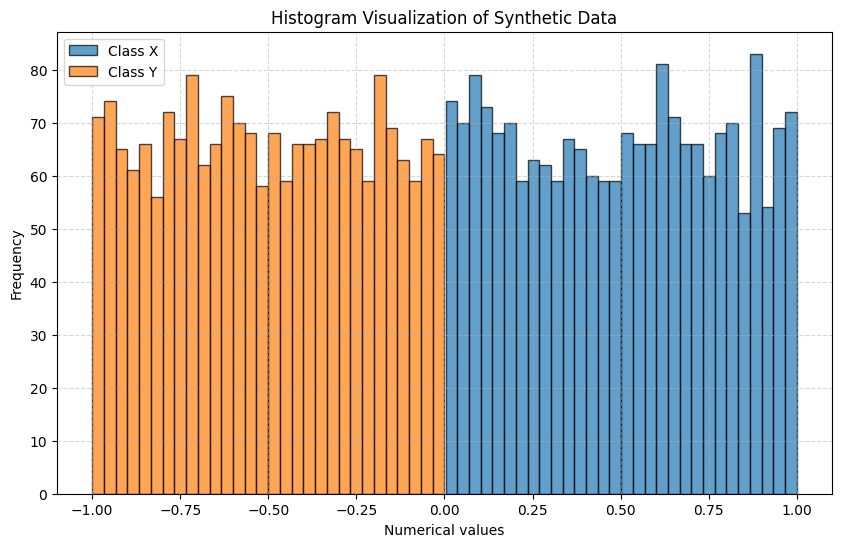

In [2]:
# Setting seed for reproducibility
np.random.seed(42)

# Generating Class X data: [u, 0]
u = np.random.uniform(0, 1, 2000)
X_class = np.column_stack((u, np.zeros(2000)))
labels_X = np.zeros(2000)  # Label 0 for Class X

# Generating Class Y data: [0, z]
z = np.random.uniform(-1, 0, 2000)
Y_class = np.column_stack((z, np.zeros(2000)))
labels_Y = np.ones(2000)   # Label 1 for Class Y

# Combining and splitting
X_data = np.vstack((X_class, Y_class))
Y_labels = np.concatenate((labels_X, labels_Y))

X_train, X_test, y_train, y_test = train_test_split(X_data, Y_labels, test_size=0.2, random_state=42)

# Visualization
plt.figure(figsize=(10, 6))
plt.hist(X_class[:, 0], bins=30, alpha=0.7, label='Class X', edgecolor='black')
plt.hist(Y_class[:, 0], bins=30, alpha=0.7, label='Class Y', edgecolor='black')
plt.title('Histogram Visualization of Synthetic Data')
plt.xlabel('Numerical values')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Part B: KNN Classification with Euclidean Distance

**Task:** Train a KNN classifier using Euclidean distance for $k \in \{1, 5, 20, 50\}$. Evaluate and report the accuracy on the test set.

**Analysis:** Since the data points from Class X and Class Y lie exclusively on the positive X-axis and negative Y-axis respectively, they are perfectly separable. Thus, the KNN classifier easily achieves 100% accuracy across all values of $k$ without any overlap issues.

In [3]:
k_values = [1, 5, 20, 50]

print("Evaluation with Euclidean Distance:")
for k in k_values:
    knn_euc = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_euc.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, knn_euc.predict(X_test))
    print(f"k = {k}, Accuracy = {accuracy:.4f}")

Evaluation with Euclidean Distance:
k = 1, Accuracy = 1.0000
k = 5, Accuracy = 1.0000
k = 20, Accuracy = 1.0000
k = 50, Accuracy = 1.0000


## Part C: KNN Classification with Cosine Distance

**Task:** Train the KNN classifier using Cosine distance for the same $k$ values and compare the results.

**Analysis:** The cosine distance between any point in Class X and any point in Class Y is exactly 1.0 because their vectors are strictly orthogonal (their dot product is precisely 0). Conversely, the cosine distance between points within the same class is 0.0. Therefore, the classifier continues to perfectly distinguish between the two classes, yielding 100% accuracy just like the Euclidean distance metric.

In [4]:
print("Evaluation with Cosine Distance:")
for k in k_values:
    knn_cos = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn_cos.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, knn_cos.predict(X_test))
    print(f"k = {k}, Accuracy = {accuracy:.4f}")

Evaluation with Cosine Distance:
k = 1, Accuracy = 1.0000
k = 5, Accuracy = 1.0000
k = 20, Accuracy = 1.0000
k = 50, Accuracy = 1.0000


## Part D: Effect of Gaussian Noise

**Task:** Add Gaussian noise (mean=0, std=0.1) to both the training and testing datasets. Train and evaluate the KNN classifier with Euclidean distance.

**Analysis:** The addition of Gaussian noise scatters the data points away from the exact axes. Points near the origin (where the margins between the two classes are exceptionally narrow) are highly susceptible to crossing the implicit decision boundary. This overlap near the origin leads to misclassifications. Increasing $k$ generally helps smooth out the decision boundary and makes the model less sensitive to the random noise, often yielding a slight improvement in accuracy compared to $k=1$.

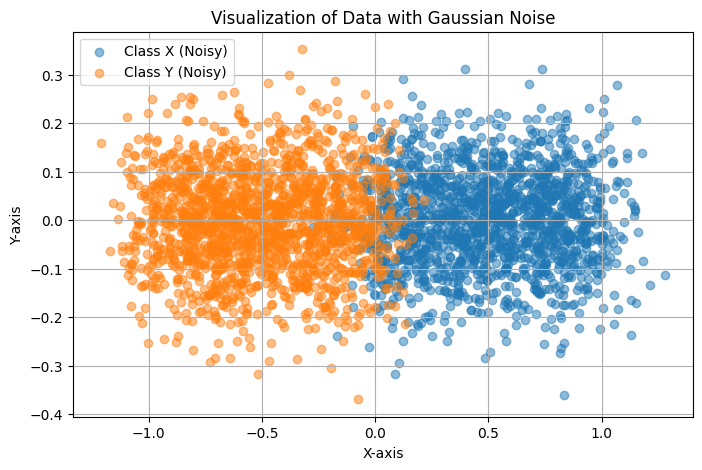

Evaluation with Gaussian Noise (Euclidean Distance):
k = 1, Accuracy = 0.9513
k = 5, Accuracy = 0.9587
k = 20, Accuracy = 0.9625
k = 50, Accuracy = 0.9600


In [5]:
# Adding Gaussian noise to the dataset
noise_train = np.random.normal(0, 0.1, X_train.shape)
noise_test = np.random.normal(0, 0.1, X_test.shape)

X_train_noisy = X_train + noise_train
X_test_noisy = X_test + noise_test

# Visualization of Noisy Data
plt.figure(figsize=(8, 5))
plt.scatter(X_train_noisy[y_train==0][:, 0], X_train_noisy[y_train==0][:, 1], label='Class X (Noisy)', alpha=0.5)
plt.scatter(X_train_noisy[y_train==1][:, 0], X_train_noisy[y_train==1][:, 1], label='Class Y (Noisy)', alpha=0.5)
plt.title('Visualization of Data with Gaussian Noise')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)
plt.show()

print("Evaluation with Gaussian Noise (Euclidean Distance):")
for k in k_values:
    knn_noisy = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_noisy.fit(X_train_noisy, y_train)
    accuracy = accuracy_score(y_test, knn_noisy.predict(X_test_noisy))
    print(f"k = {k}, Accuracy = {accuracy:.4f}")

## Part E: Imbalanced Dataset Evaluation

**Task:** Create a highly imbalanced dataset containing 10,000 instances from Class X and 1,000 instances from Class Y. Split it 80/20 and evaluate using Euclidean distance.

**Analysis:** Because this specific imbalanced dataset is free of noise, the vectors remain strictly orthogonal on their respective axes, meaning they are perfectly separable. Thus, the accuracy remains incredibly high. However, it is an important ML principle that if noise or overlapping distributions were present, highly imbalanced datasets would cause algorithms utilizing large $k$ values to naturally bias predictions towards the dominant majority class (Class X).

In [6]:
# Generating Imbalanced Data
u_imb = np.random.uniform(0, 1, 10000)
X_imb_class = np.column_stack((u_imb, np.zeros(10000)))
labels_X_imb = np.zeros(10000)

z_imb = np.random.uniform(-1, 0, 1000)
Y_imb_class = np.column_stack((np.zeros(1000), z_imb))
labels_Y_imb = np.ones(1000)

X_imb_data = np.vstack((X_imb_class, Y_imb_class))
Y_imb_labels = np.concatenate((labels_X_imb, labels_Y_imb))

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(X_imb_data, Y_imb_labels, test_size=0.2, random_state=42)

print("Imbalanced Data Evaluation (Euclidean Distance):")
for k in k_values:
    knn_imb = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_imb.fit(X_train_imb, y_train_imb)
    accuracy = accuracy_score(y_test_imb, knn_imb.predict(X_test_imb))
    print(f"k = {k}, Accuracy = {accuracy:.4f}")

Imbalanced Data Evaluation (Euclidean Distance):
k = 1, Accuracy = 1.0000
k = 5, Accuracy = 1.0000
k = 20, Accuracy = 1.0000
k = 50, Accuracy = 0.9986
